# Demonstration and Evaluation of `ahmad_2017_identity`

This notebook demonstrates the usage and evaluates the properties of the covariance hypothesis testing method `ahmad_2017_identity` from `covtest.methods.hypothesis_identity`.

## Hypothesis Tested
We test the null hypothesis:
$$H_0: \Sigma_1 = \Sigma_2 = \dots = \Sigma_g = I_p$$
against the alternative hypothesis that at least one covariance matrix differs from the identity $I_p$, across $g \ge 2$ independent groups.

## Method Description
Ahmad (2017) multi-sample test for a common identity covariance matrix using pooled location-invariant U-statistic estimators.

## Notebook Contents
1. **Setup and Imports**
2. **Basic Usage**
3. **P-value Calibration Under the Null**: Checking uniformity of p-values under different distributions (Gaussian, Student-t, Laplace).
4. **Power Analysis Under Alternatives**: Power curves across different sample sizes ($n$), dimensions ($p$), and alternative covariance structures.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Ensure project root is in the path
sys.path.insert(0, os.path.abspath('..'))

from covtest.methods.hypothesis_identity import ahmad_2017_identity
from covtest.simulation.generate_data import generate_heavy_tailed_samples
from covtest.simulation.generate_covariances import (
    generate_toeplitz_cov,
    generate_spiked_covariance
)
from covtest.diagnostics.evaluate_pvalues import analyze_pvalues
from covtest.plotting.null import plot_pvalue_diagnostics_grid
from covtest.plotting.alternative import plot_power_curve, plot_power_heatmap

# Set up plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
rng = np.random.default_rng(42)


## 2. Basic Usage

Let's run a single test on synthetic data from two groups generated under the null hypothesis ($H_0: \Sigma_1 = \Sigma_2 = I_p$).


In [2]:
n1, n2, p = 100, 120, 50
null_cov = np.eye(p)

# Generate data under the null
X1 = generate_heavy_tailed_samples(null_cov, n1, dist_type="normal", rng=rng)
X2 = generate_heavy_tailed_samples(null_cov, n2, dist_type="normal", rng=rng)

# Run the test
result = ahmad_2017_identity([X1, X2])
print("Test Results:")
for k, v in result.items():
    print(f"  {k}: {v}")


Test Results:
  stat: -0.024349407318859637
  p_value: 0.509713048271974


## 3. P-value Calibration Under the Null

Under the null hypothesis, the p-values computed by the test should theoretically be uniformly distributed over $[0, 1]$. We will evaluate this calibration by running $M = 300$ simulations under three different scenarios:
- **Scenario A**: Multivariate Normal distribution (standard).
- **Scenario B**: Multivariate Student-t distribution (heavy-tailed, df=3), which violates standard normality assumptions.
- **Scenario C**: Multivariate Laplace distribution.


In [3]:
M = 300
n, p = 100, 30
null_cov = np.eye(p)

scenarios = {
    "Normal": ("normal", {}),
    "Student-t (df=3)": ("t", {"df": 3}),
    "Laplace": ("laplace", {})
}

pvals_dict = {}

print("Running null simulations...")
for name, (dist, opts) in scenarios.items():
    pvals = []
    for _ in range(M):
        X1 = generate_heavy_tailed_samples(null_cov, n, dist_type=dist, options=opts, rng=rng)
        X2 = generate_heavy_tailed_samples(null_cov, n + 20, dist_type=dist, options=opts, rng=rng)
        res = ahmad_2017_identity([X1, X2])
        pvals.append(res["p_value"])
    pvals_dict[name] = np.array(pvals)
    print(f"  Completed {name}")


Running null simulations...
  Completed Normal
  Completed Student-t (df=3)
  Completed Laplace


### Diagnostic Analysis of Null P-values

We use the package's `analyze_pvalues` diagnostic utility to check the uniformity of p-values for each scenario.


In [4]:
for name, pvals in pvals_dict.items():
    diagnostics = analyze_pvalues(pvals)
    print(f"=== {name} Scenario Diagnostics ===")
    print(f"  KS Test p-value: {diagnostics['ks']['pval']:.4f}")
    print(f"  Anderson-Darling stat: {diagnostics['ad']['stat']:.4f}")
    print(f"  Genomic Inflation Factor (lambda): {diagnostics['inflation_factor']:.4f}")
    print(f"  Storey's pi0: {diagnostics['storey_pi0']:.4f}")
    print()


=== Normal Scenario Diagnostics ===
  KS Test p-value: 0.5571
  Anderson-Darling stat: 326.0156
  Genomic Inflation Factor (lambda): 1.1748
  Storey's pi0: 0.9333

=== Student-t (df=3) Scenario Diagnostics ===
  KS Test p-value: 0.0000
  Anderson-Darling stat: inf
  Genomic Inflation Factor (lambda): 1.3640
  Storey's pi0: 0.9800

=== Laplace Scenario Diagnostics ===
  KS Test p-value: 0.0128
  Anderson-Darling stat: 503.5414
  Genomic Inflation Factor (lambda): 0.9642
  Storey's pi0: 1.0000



/Users/austin/Forks/scikit-covtest/covtest/diagnostics/evaluate_pvalues.py:168: RuntimeWarning: divide by zero encountered in log
  term1 = (2 * i - 1) * np.log(sorted_p)
/Users/austin/Forks/scikit-covtest/covtest/diagnostics/evaluate_pvalues.py:169: RuntimeWarning: divide by zero encountered in log
  term2 = (2 * (len(pvals) - i) + 1) * np.log(1 - sorted_p[::-1])


### Visualizing P-value Calibration
Let's plot the ECDF, histogram, and QQ-plot for each scenario to visually assess the uniformity of the null p-values.


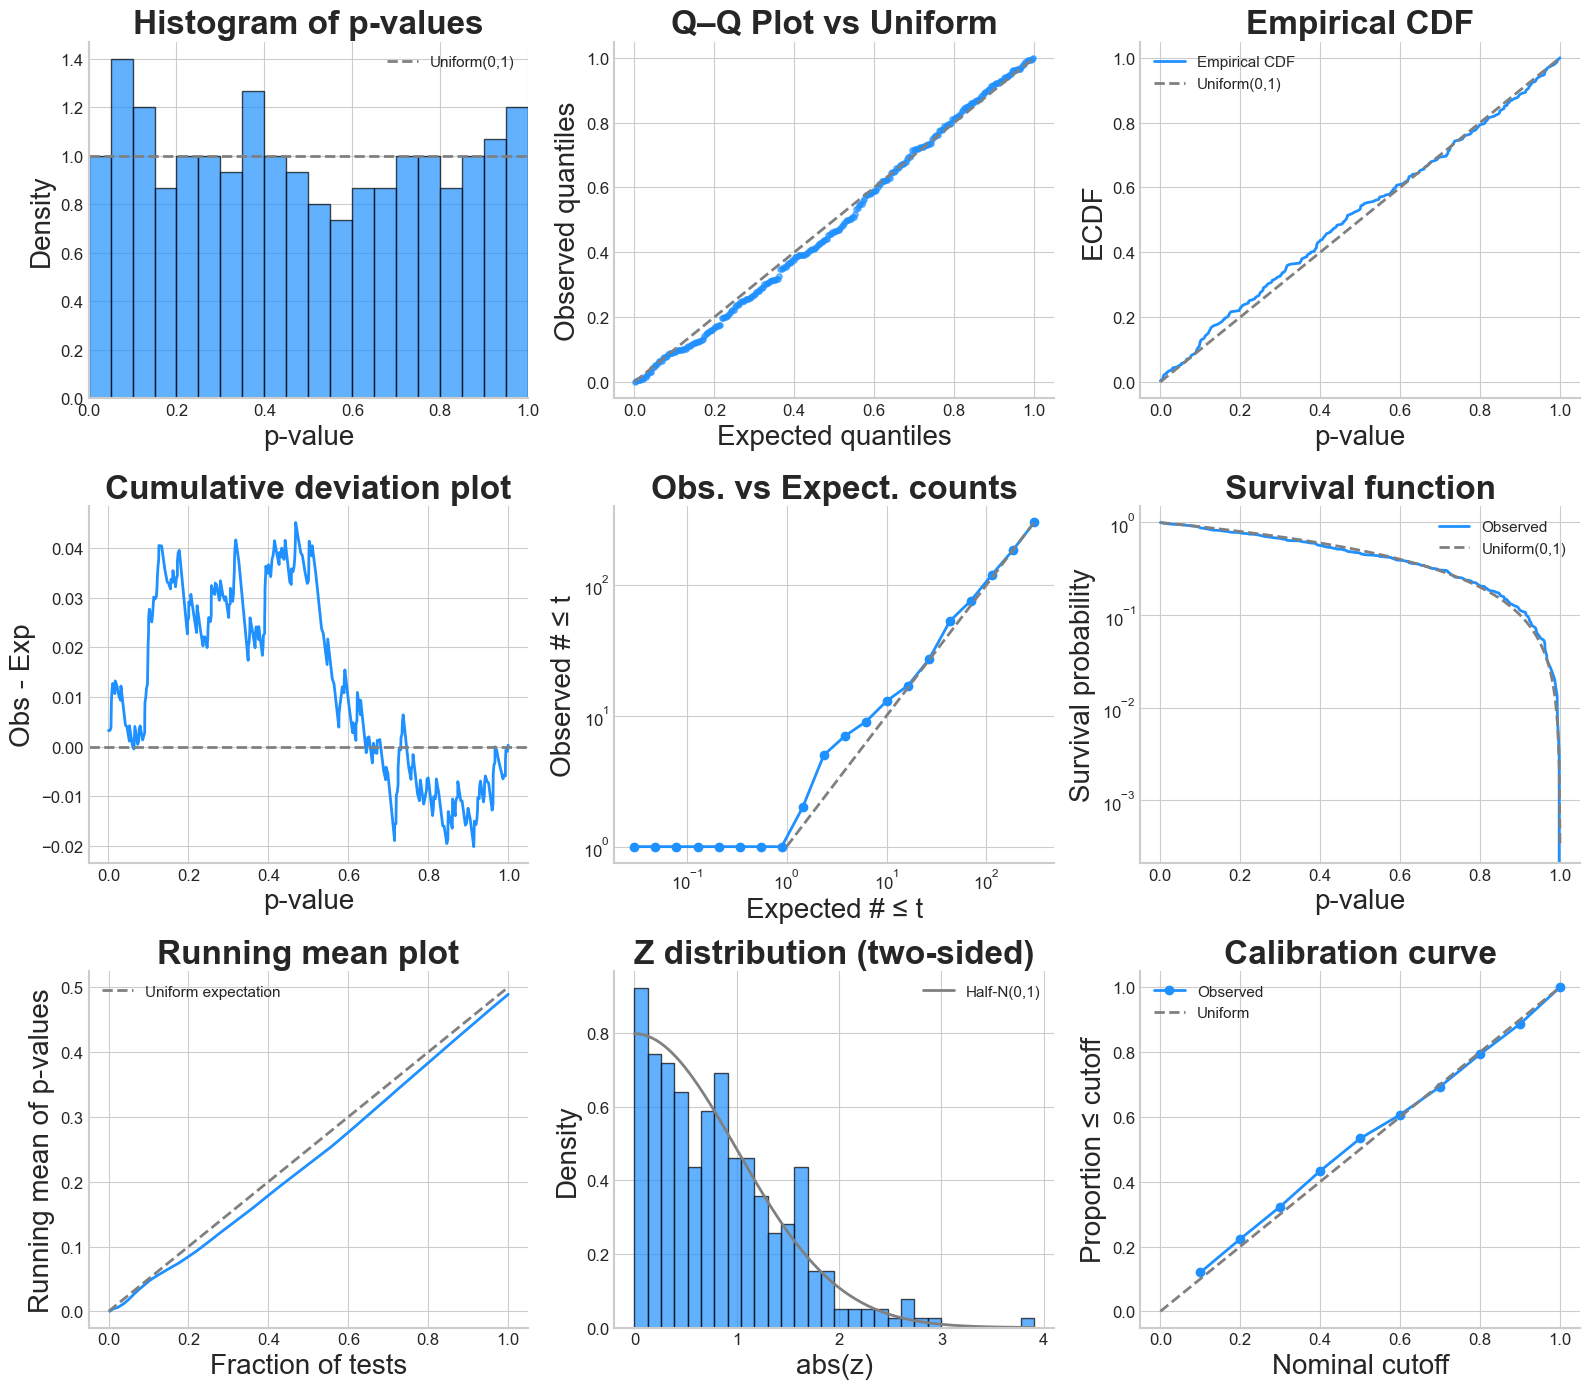

<Figure size 640x480 with 0 Axes>

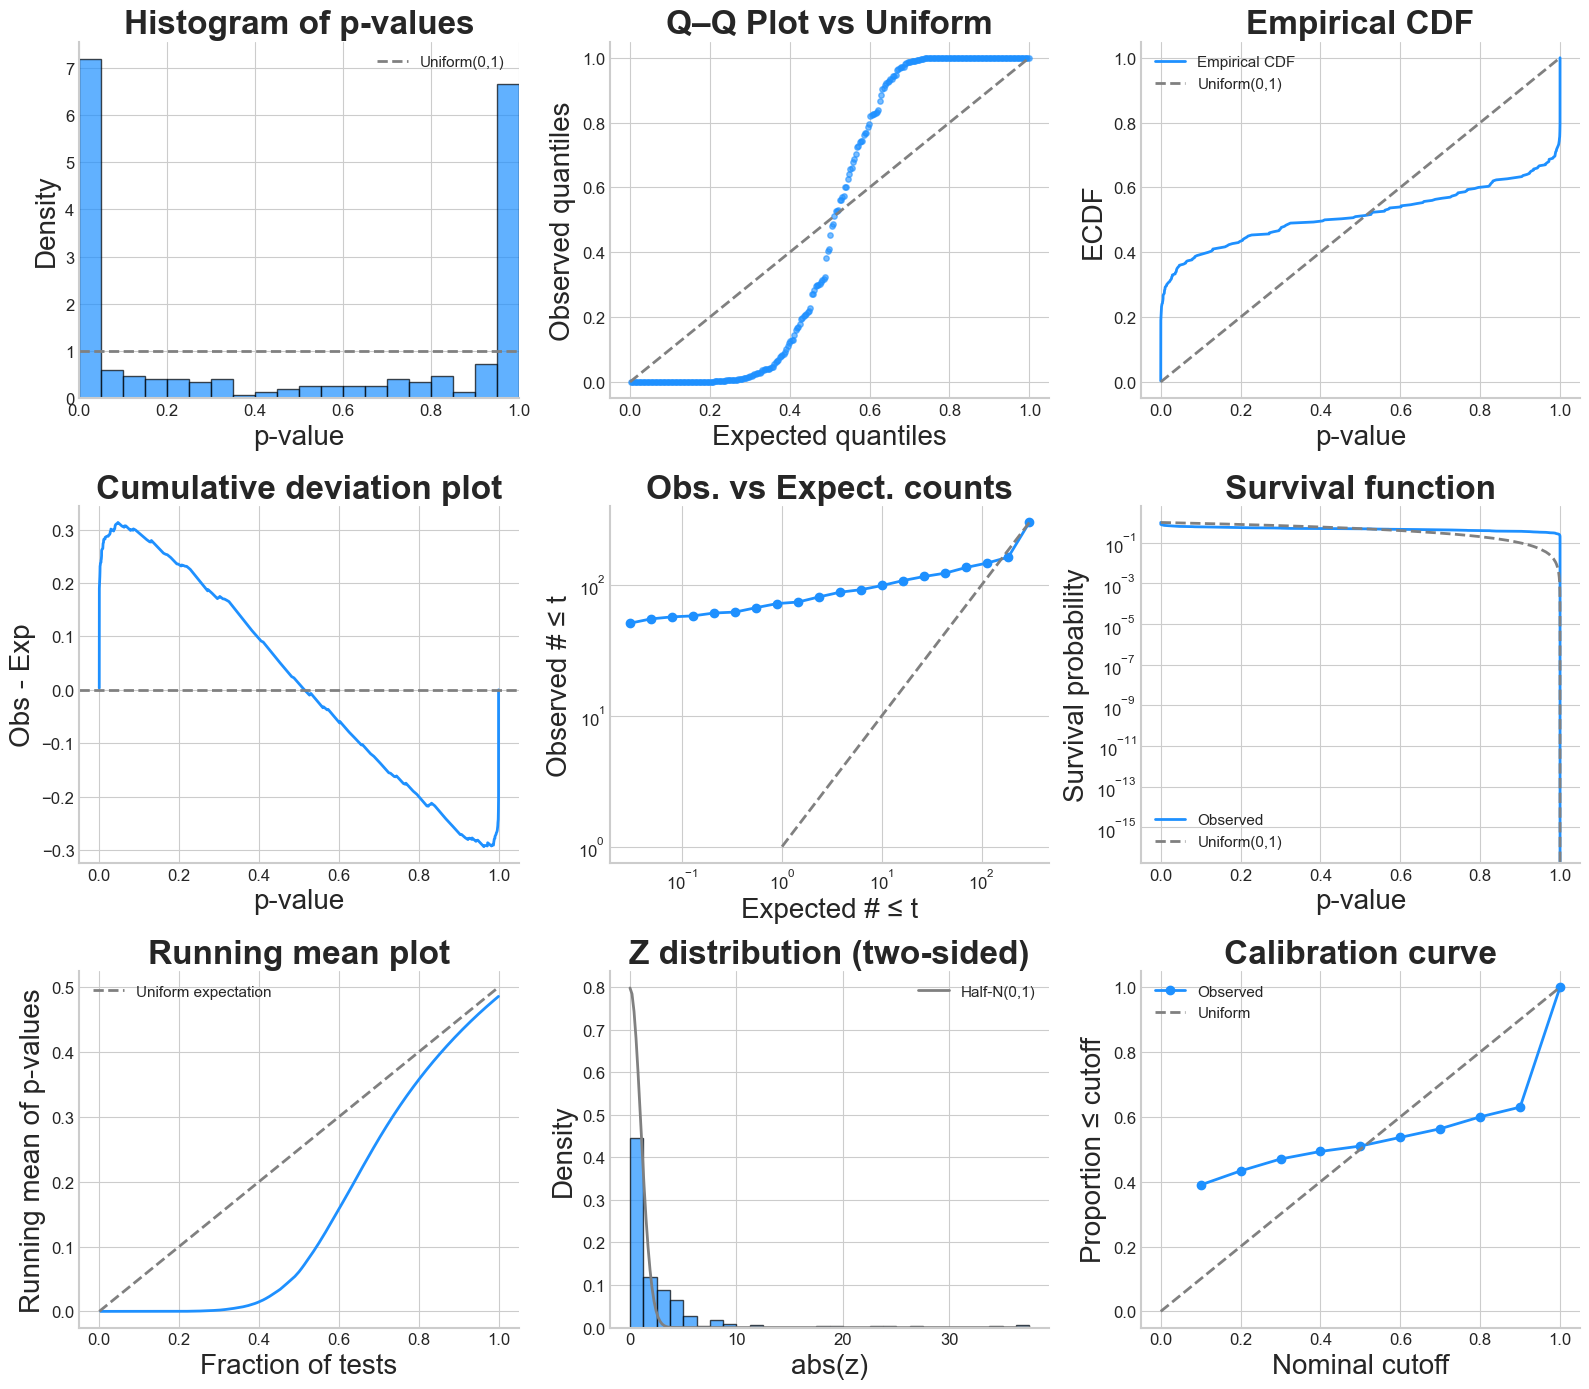

<Figure size 640x480 with 0 Axes>

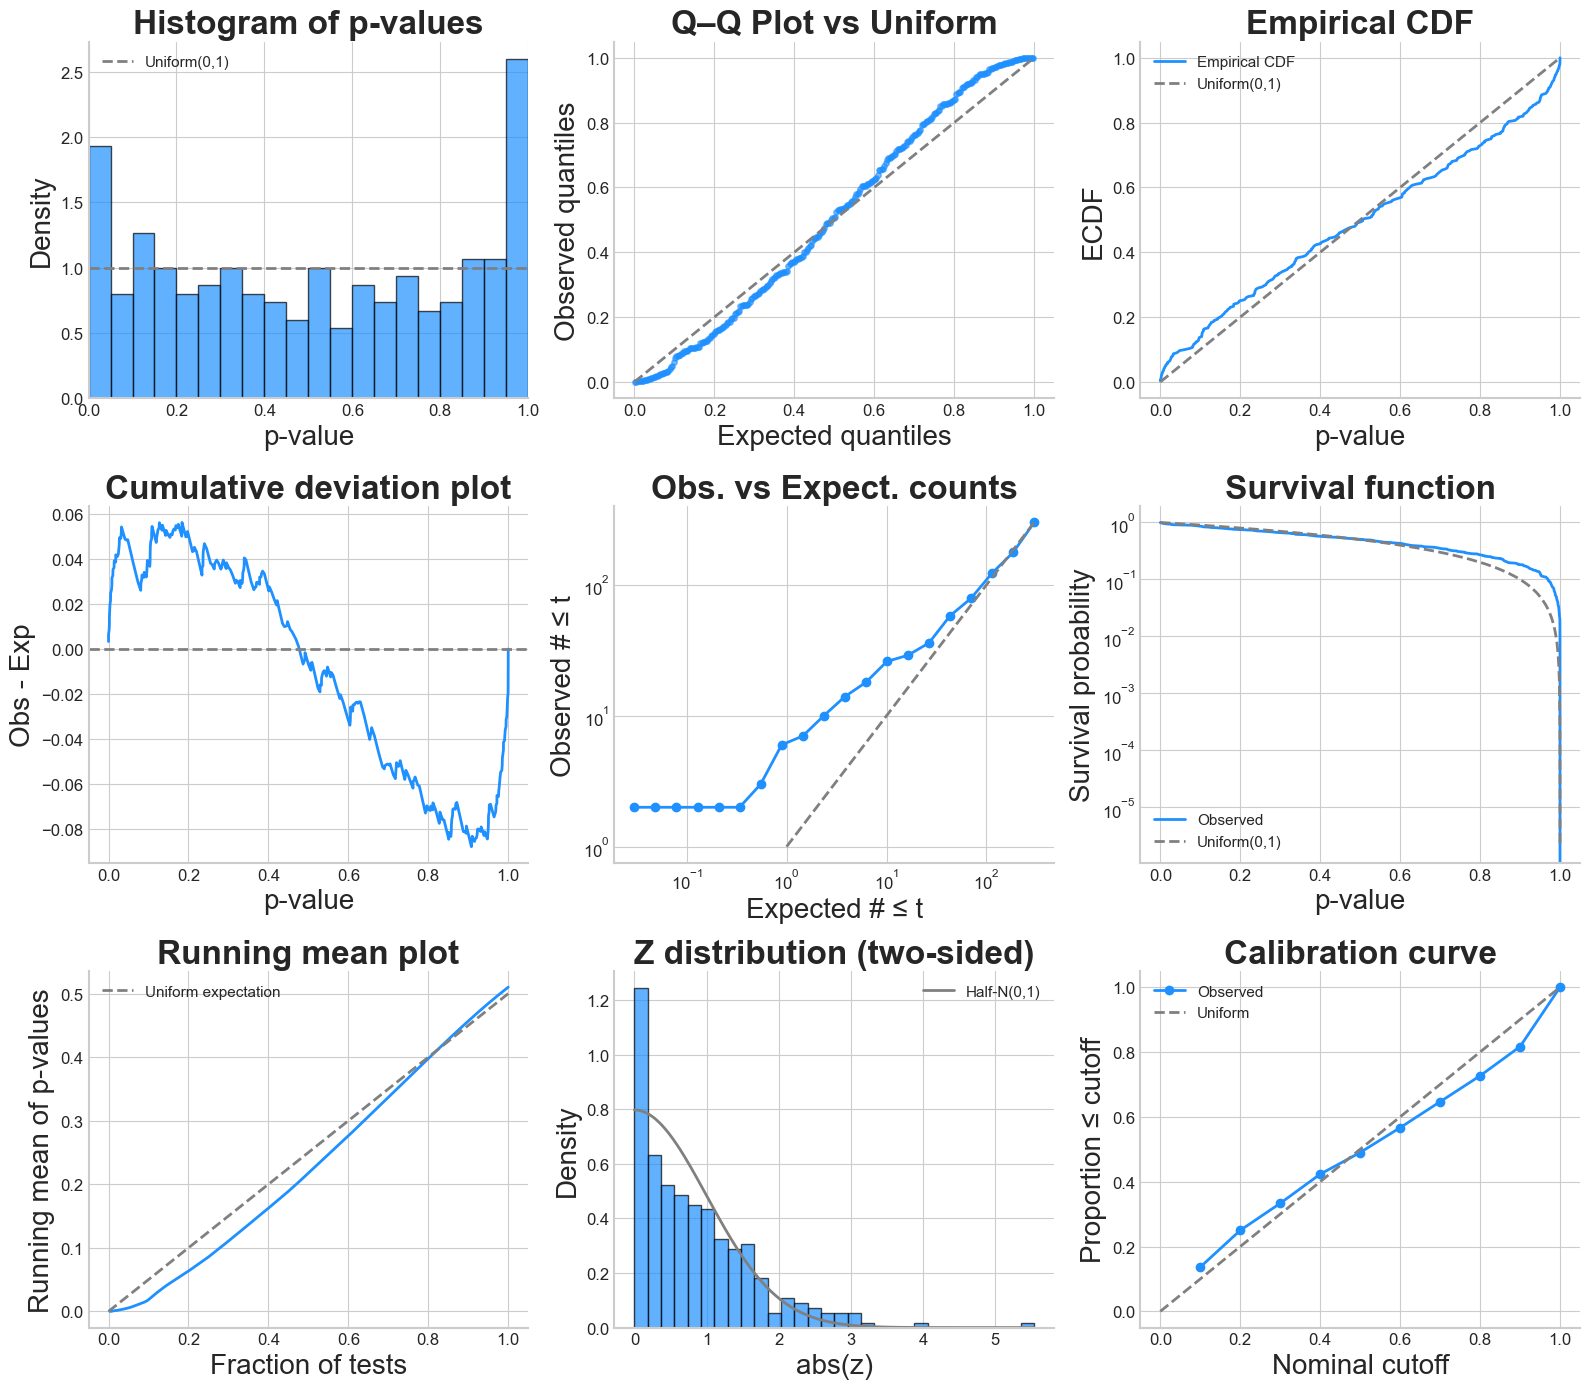

<Figure size 640x480 with 0 Axes>

In [5]:
for name, pvals in pvals_dict.items():
    fig = plot_pvalue_diagnostics_grid(pvals)
    fig.suptitle(f"P-value Calibration Grid - {name} Null", fontsize=16)
    plt.tight_layout()
    plt.show()


## 4. Power Analysis Under Alternatives

We evaluate the statistical power of the `ahmad_2017_identity` test. We consider alternatives where the second group has a non-identity covariance structure:
1. **Spiked Covariance Matrix**: A few eigenvalues are spiked (inflated) in Group 2.
2. **Toeplitz (AR(1)) Covariance Matrix**: Group 2 has autoregressive correlations.

### Power vs. Alternative Strength


In [14]:
M_alt = 100
n, p = 100, 30

# Spiked alternative for Group 2
spike_values = np.array([1.0, 1.5, 2.0, 3.0, 4.5, 6.0,1000.0])
pvals_spiked = []

for spike in spike_values:
    col_pvals = []
    cov_matrix = generate_spiked_covariance(p, spike_eigenvalue=spike, num_spikes=1, rng=rng) if spike > 1.0 else np.eye(p)
    for _ in range(M_alt):
        X1 = generate_heavy_tailed_samples(np.eye(p), n, dist_type="normal", rng=rng)
        X2 = generate_heavy_tailed_samples(cov_matrix, n + 20, dist_type="normal", rng=rng)
        res = ahmad_2017_identity([X1, X2])
        col_pvals.append(res["p_value"])
    pvals_spiked.append(col_pvals)

pvals_spiked = np.array(pvals_spiked).T


In [12]:
# Toeplitz alternative for Group 2
rho_values = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
pvals_toeplitz = []

for rho in rho_values:
    col_pvals = []
    cov_matrix = generate_toeplitz_cov(p, rho) if rho > 0.0 else np.eye(p)
    for _ in range(M_alt):
        X1 = generate_heavy_tailed_samples(np.eye(p), n, dist_type="normal", rng=rng)
        X2 = generate_heavy_tailed_samples(cov_matrix, n + 20, dist_type="normal", rng=rng)
        res = ahmad_2017_identity([X1, X2])
        col_pvals.append(res["p_value"])
    pvals_toeplitz.append(col_pvals)

pvals_toeplitz = np.array(pvals_toeplitz).T


Plotting power curve for Spiked Covariance alternative in Group 2:


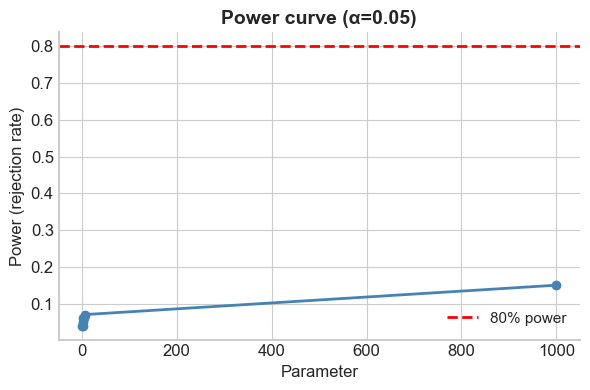

In [15]:
# Plotting spiked power curve
print("Plotting power curve for Spiked Covariance alternative in Group 2:")
plot_power_curve(pvals_spiked, spike_values, alpha=0.05)


Plotting power curve for Toeplitz Covariance alternative in Group 2:


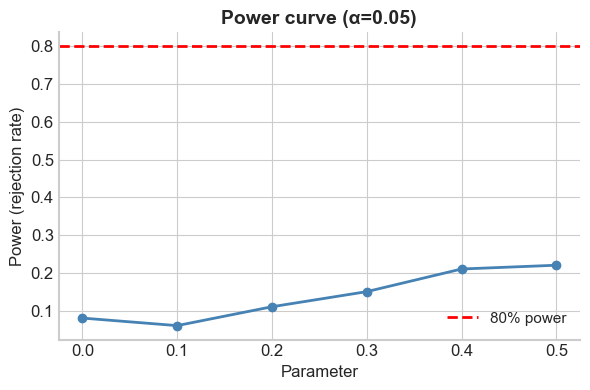

In [9]:
# Plotting Toeplitz power curve
print("Plotting power curve for Toeplitz Covariance alternative in Group 2:")
plot_power_curve(pvals_toeplitz, rho_values, alpha=0.05)


### Power Heatmap Over Sample Sizes ($n$) and Dimensions ($p$)
We now analyze how power varies over a grid of sample sizes and dimensions under a fixed spiked alternative covariance in Group 2.


Running grid simulations...
Plotting power heatmap over sample sizes (n) and dimensions (p):


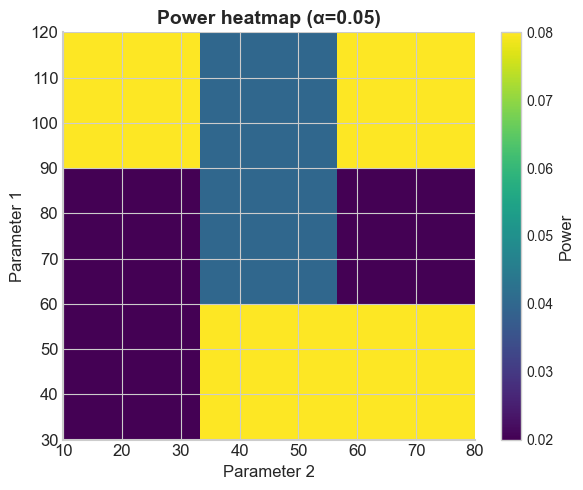

In [10]:
sample_sizes = np.array([30, 60, 120])
dimensions = np.array([10, 30, 80])
pvals_grid = []
spike_val = 3.5

print("Running grid simulations...")
for n_val in sample_sizes:
    row_pvals = []
    for p_val in dimensions:
        cell_pvals = []
        cov_matrix = generate_spiked_covariance(p_val, spike_eigenvalue=spike_val, num_spikes=1, rng=rng)
        for _ in range(50):
            X1 = generate_heavy_tailed_samples(np.eye(p_val), n_val, dist_type="normal", rng=rng)
            X2 = generate_heavy_tailed_samples(cov_matrix, n_val + 20, dist_type="normal", rng=rng)
            res = ahmad_2017_identity([X1, X2])
            cell_pvals.append(res["p_value"])
        row_pvals.append(cell_pvals)
    pvals_grid.append(row_pvals)

pvals_grid = np.transpose(np.array(pvals_grid), (2, 0, 1))

print("Plotting power heatmap over sample sizes (n) and dimensions (p):")
plot_power_heatmap(pvals_grid, sample_sizes, dimensions, alpha=0.05)
